In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns
from scipy.stats import (
    shapiro,
    levene,
    ttest_ind,
    mannwhitneyu,
    chi2_contingency,
    f_oneway,
    skew,
    kurtosis
)  # Statistical Tests

import statsmodels.api as sm  # Regression
from statsmodels.stats.outliers_influence import variance_inflation_factor  # Model Evaluation
import warnings  # Ignore warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("insurance.csv")
print("Dataset Loaded Successfully!\n")

print(df.head())

print("\nShape:")
print(df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()
print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

print("\nSummary Statistics")
print(df.describe())

Dataset Loaded Successfully!

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Shape:
(1338, 7)

Columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate Rows: 1

Dataset Shape After Removing Duplicates:
(1337, 7)

Summary Statistics
               age          bmi     children       charges
count  1337.000000  1337.

In [6]:
# Exploratory Data Analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

print("\n Mean ")
print(df[numerical_cols].mean())

print("\n Median ")
print(df[numerical_cols].median())

print("\n Standard Deviation ")
print(df[numerical_cols].std())

Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
print("\n Interquartile Range: ")
print(IQR)

print("\n Skewness ")
for col in numerical_cols:
    print(f"{col}: {df[col].skew():.3f}")

print("\n Kurtosis ")
for col in numerical_cols:
    print(f"{col}: {df[col].kurtosis():.3f}")

Numerical Columns:
Index(['age', 'bmi', 'children', 'charges'], dtype='object')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='object')

 Mean 
age            39.222139
bmi            30.663452
children        1.095737
charges     13279.121487
dtype: float64

 Median 
age           39.0000
bmi           30.4000
children       1.0000
charges     9386.1613
dtype: float64

 Standard Deviation 
age            14.044333
bmi             6.100468
children        1.205571
charges     12110.359656
dtype: float64

 Interquartile Range: 
age            24.00000
bmi             8.41000
children        2.00000
charges     11911.37345
dtype: float64

 Skewness 
age: 0.055
bmi: 0.284
children: 0.937
charges: 1.515

 Kurtosis 
age: -1.244
bmi: -0.053
children: 0.201
charges: 1.604


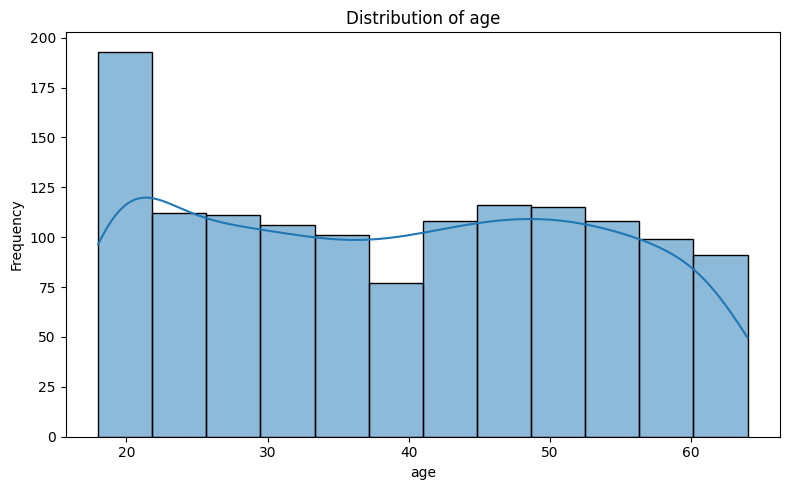

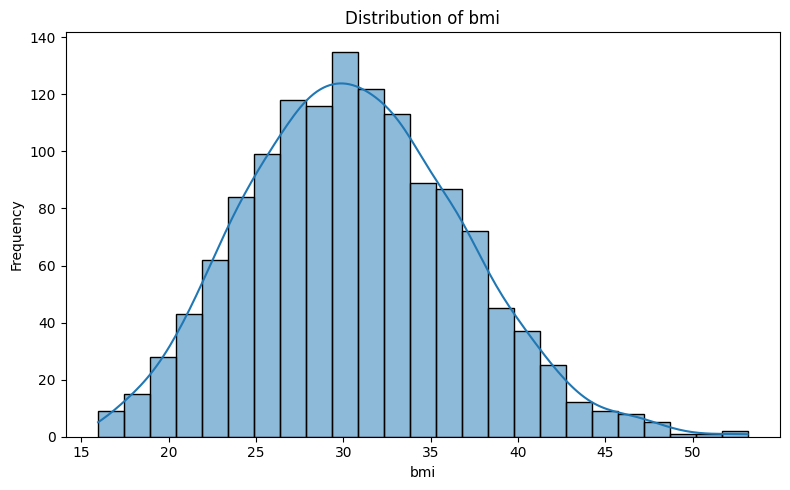

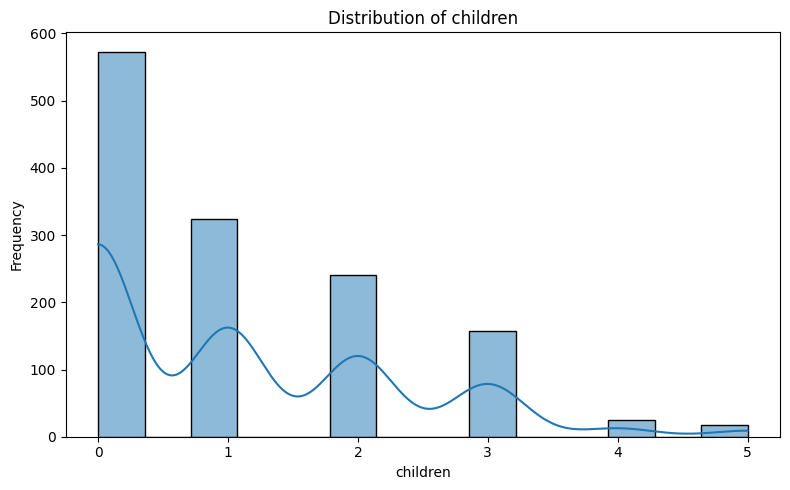

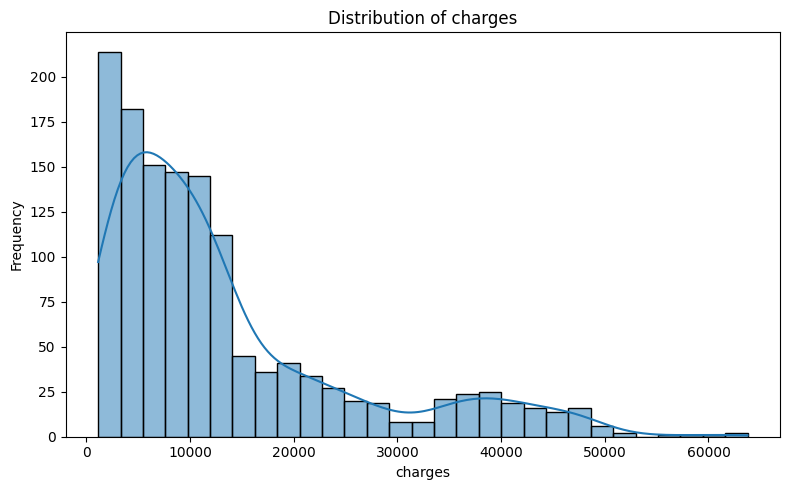

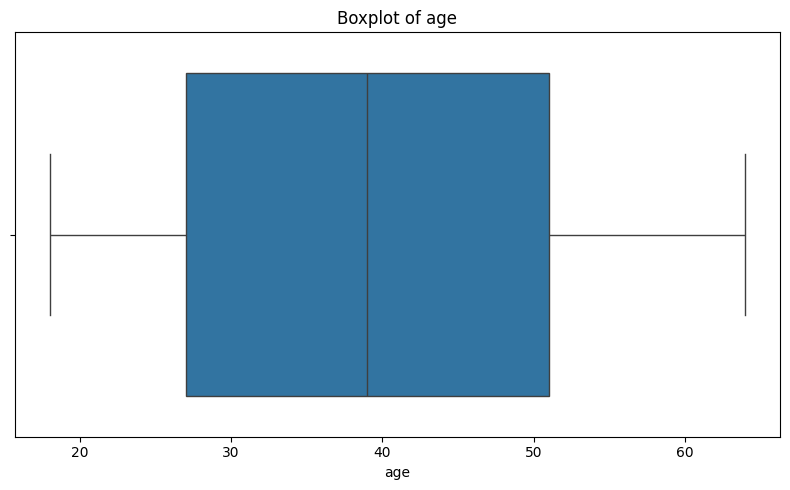

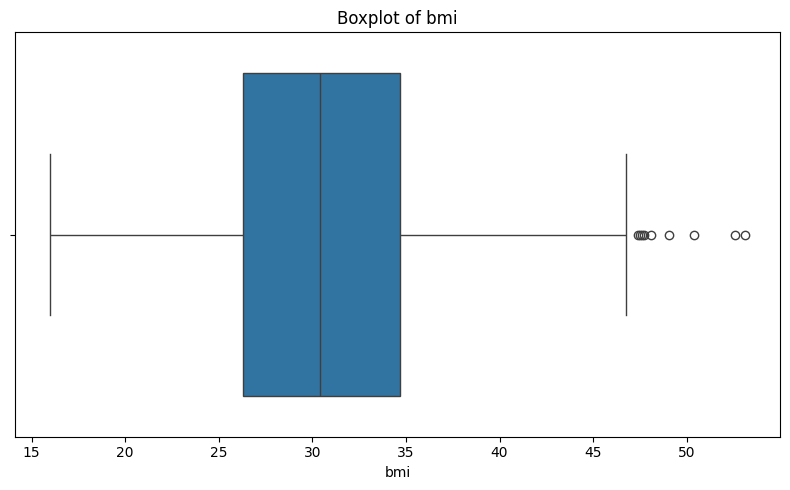

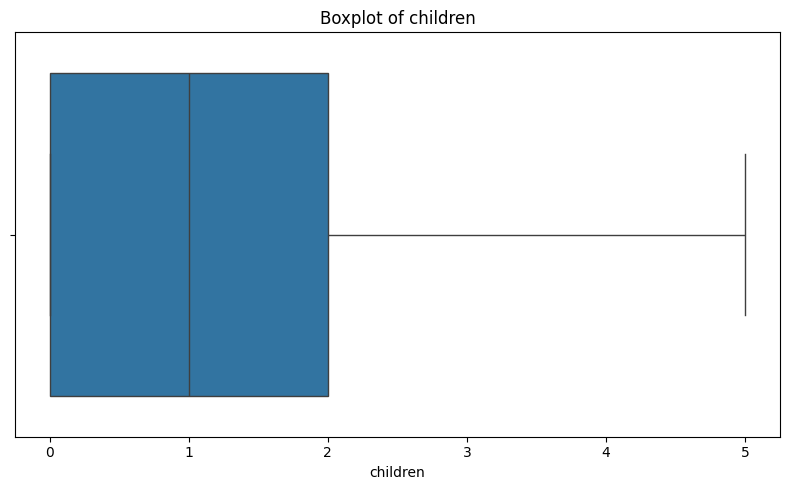

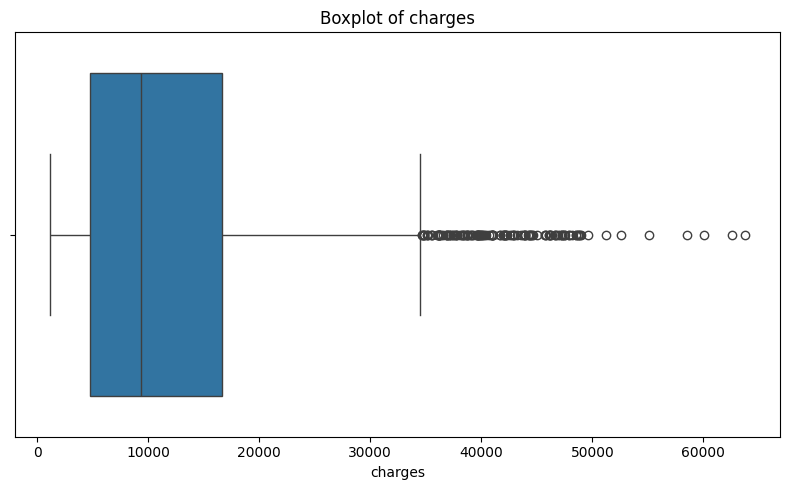

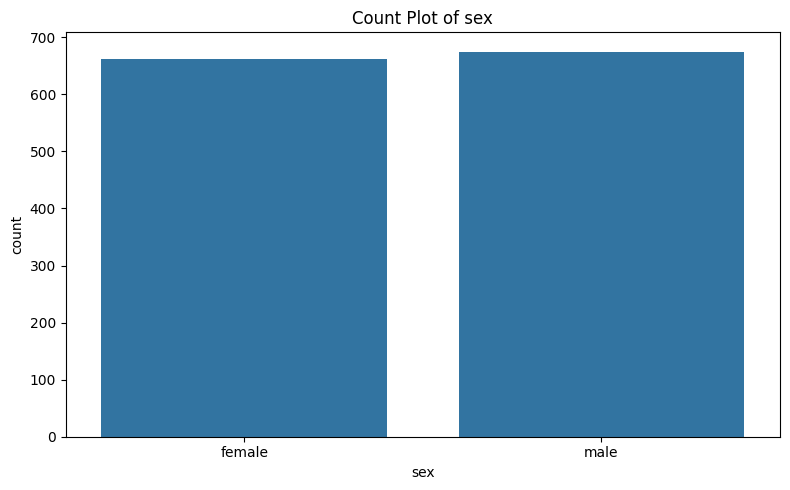

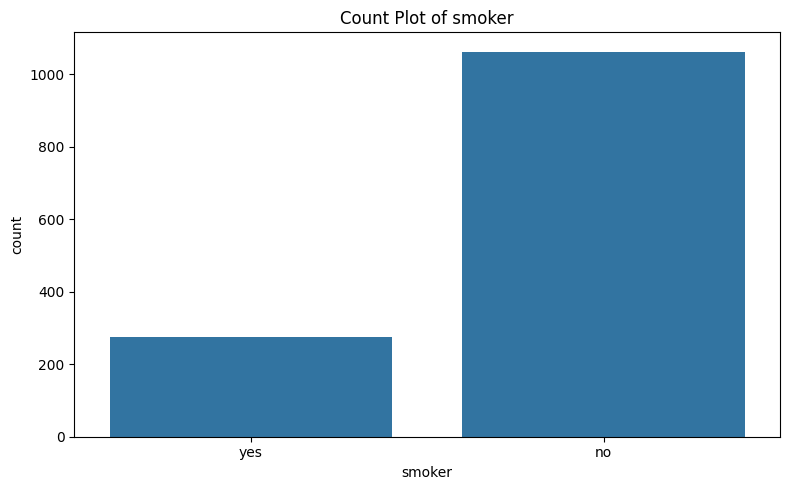

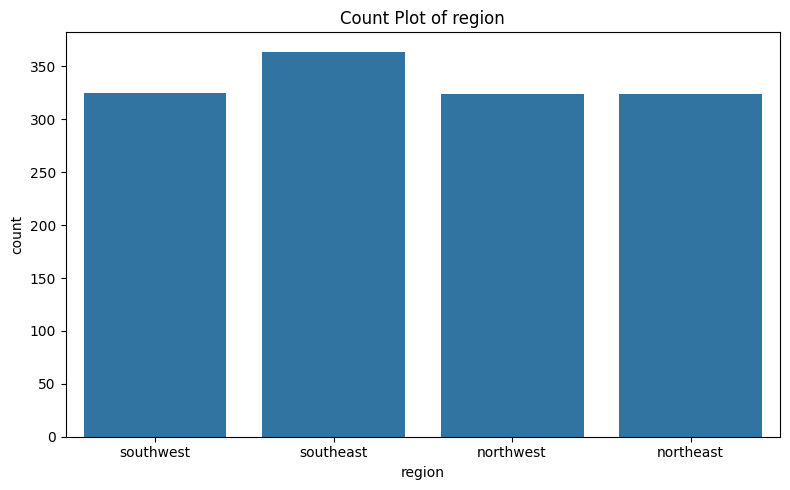

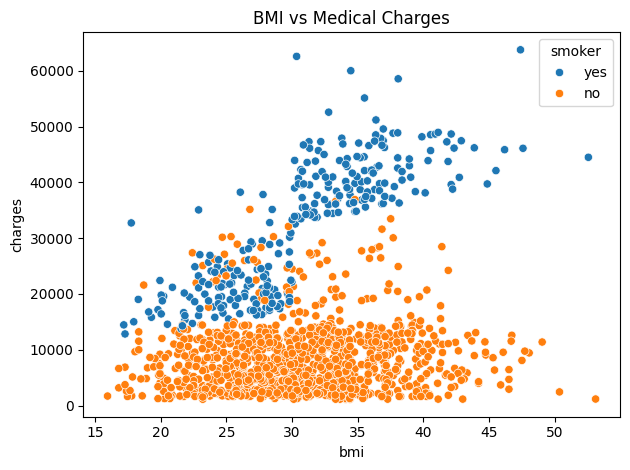

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


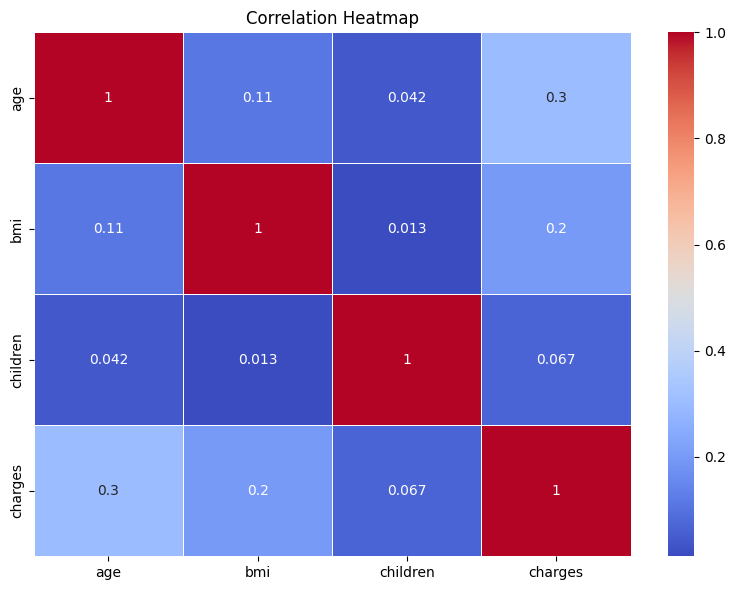

In [7]:
# Histogram + KDE
for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Boxplots
for col in numerical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

# Count Plots
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(x=col, data=df)
    plt.title(f"Count Plot of {col}")
    plt.tight_layout()
    plt.show()

# Scatter Plots
sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker" )
plt.title("BMI vs Medical Charges")
plt.tight_layout()
plt.show()

# Correlation Matrix
correlation = df[numerical_cols].corr()
print(correlation)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5  )
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [9]:
# Hypothesis Test
# Smokers vs Non-Smokers
smoker = df[df["smoker"] == "yes"]["charges"]
non_smoker = df[df["smoker"] == "no"]["charges"]

print("Hypothesis Test 1")
print("H0 : Mean medical charges are the same for smokers and non-smokers.")
print("H1 : Mean medical charges are different for smokers and non-smokers.")

# Normality Test
print("\nShapiro-Wilk Test")
smoker_p = shapiro(smoker).pvalue
non_smoker_p = shapiro(non_smoker).pvalue
print("Smoker p-value :", smoker_p)
print("Non-Smoker p-value :", non_smoker_p)

# Equal Variance Test
print("\nLevene's Test")
levene_p = levene(smoker, non_smoker).pvalue
print("p-value :", levene_p)

# Automatic Test Selection
alpha = 0.05
if smoker_p > alpha and non_smoker_p > alpha:
    print("\nBoth groups are normally distributed.")
    equal_var = True if levene_p > alpha else False
    statistic, p_value = ttest_ind(
        smoker,
        non_smoker,
        equal_var=equal_var )
    test_name = "Independent Two-Sample t-test"
else:
    print("\nData is NOT normally distributed.")
    statistic, p_value = mannwhitneyu(
        smoker,
        non_smoker,
        alternative="two-sided" )
    test_name = "Mann-Whitney U Test"

print("\nSelected Test :", test_name)
print("\nTest Statistic :", statistic)
print("P-value :", p_value)
print("\nDecision")

if p_value < alpha:
    print("Reject H0")
    print("There is a statistically significant difference in medical charges between smokers and non-smokers.")
else:
    print("Fail to Reject H0")
    print("There is no statistically significant difference in medical charges.")

Hypothesis Test 1
H0 : Mean medical charges are the same for smokers and non-smokers.
H1 : Mean medical charges are different for smokers and non-smokers.

Shapiro-Wilk Test
Smoker p-value : 3.6249900590074145e-09
Non-Smoker p-value : 1.5035032808411558e-28

Levene's Test
p-value : 1.670117565125241e-66

Data is NOT normally distributed.

Selected Test : Mann-Whitney U Test

Test Statistic : 283859.0
P-value : 5.74701188239214e-130

Decision
Reject H0
There is a statistically significant difference in medical charges between smokers and non-smokers.


In [ ]:
# One-Way ANOVA
northwest = df[df["region"] == "northwest"]["charges"]
northeast = df[df["region"] == "northeast"]["charges"]
southwest = df[df["region"] == "southwest"]["charges"]
southeast = df[df["region"] == "southeast"]["charges"]

print("\n\nOne-Way ANOVA")
print("H0 : Mean medical charges are equal across all regions.")
print("H1 : At least one region has a different mean medical charge.")

anova_stat, anova_p = f_oneway(
    northwest,
    northeast,
    southwest,
    southeast
)
print("\nF-statistic :", anova_stat)
print("P-value :", anova_p)

print("\nDecision")
if anova_p < alpha:
    print("Reject H0")  
    print("Average medical charges differ significantly across regions.")

else:
    print("Fail to Reject H0")
    print("Average medical charges do not differ significantly across regions.")
    



One-Way ANOVA
H0 : Mean medical charges are equal across all regions.
H1 : At least one region has a different mean medical charge.

F-statistic : 2.926139903662777
P-value : 0.03276288025444947

Decision
Reject H0
Average medical charges differ significantly across regions.


In [12]:
# Part 4: Multiple Linear Regression (OLS)
import pandas as pd
import statsmodels.api as sm

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)

# Define dependent variable (target)
y = df_encoded["charges"]

# Define independent variables (features)
X = df_encoded.drop("charges", axis=1)

# Add constant (intercept)
X = sm.add_constant(X)

# Build the OLS Regression Model
model = sm.OLS(y, X).fit()
print(model.summary())
print("\nRegression Coefficients:")
print(model.params)
print("\nP-values:")
print(model.pvalues)
print("\n95% Confidence Intervals:")
print(model.conf_int())

# R-squared
print("\nR-squared:")
print(model.rsquared)

# Adjusted R-squared
print("\nAdjusted R-squared:")
print(model.rsquared_adj)

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.0
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:31:47   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    988.227  

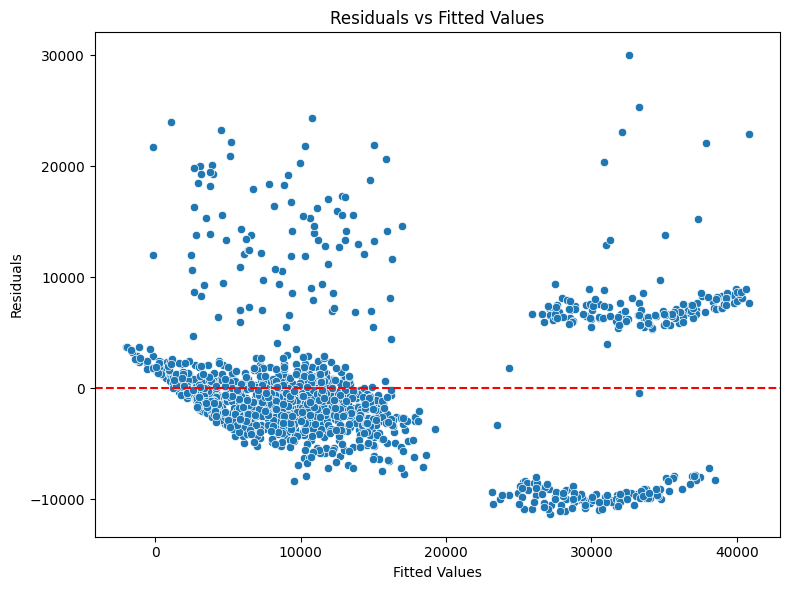

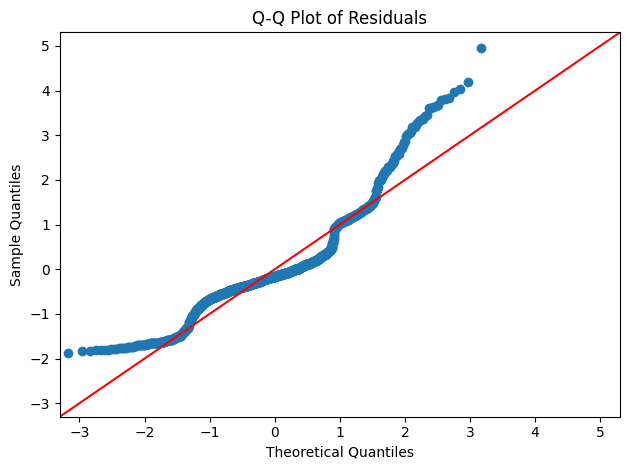


Jarque-Bera Test
-------------------------
Statistic : 716.5524474389641
P-value   : 2.5270453832630444e-156
Skewness  : 1.2105170985017681
Kurtosis  : 5.645971541398957

Omnibus Test
-------------------------
Statistic : 299.8161043630504
P-value   : 7.866112343582152e-66

Variance Inflation Factor
            Feature       VIF
0             const  1.000000
1               age  1.016794
2               bmi  1.106742
3          children  1.004017
4          sex_male  1.008944
5        smoker_yes  1.012100
6  region_northwest  1.517673
7  region_southeast  1.651779
8  region_southwest  1.529044


In [21]:
# ==========================================
# Predicted Values and Residuals
# ==========================================

predictions = model.predict(X)

# Convert to numeric arrays
predictions = pd.Series(predictions, index=y.index).astype(float)
residuals = (y.astype(float) - predictions).astype(float)

# Remove any missing values
residuals = residuals.dropna()
predictions = predictions.loc[residuals.index]

# ==========================================
# Residuals vs Fitted Plot
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(x=predictions, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.tight_layout()
plt.show()

# ==========================================
# Q-Q Plot
# ==========================================

import statsmodels.api as sm

sm.qqplot(
    residuals.to_numpy(),
    line='45', fit = True
)

plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

# ==========================================
# Jarque-Bera Test
# ==========================================

from statsmodels.stats.stattools import jarque_bera

jb_stat, jb_pvalue, skewness, kurt = jarque_bera(residuals)

print("\nJarque-Bera Test")
print("-------------------------")
print("Statistic :", jb_stat)
print("P-value   :", jb_pvalue)
print("Skewness  :", skewness)
print("Kurtosis  :", kurt)

# ==========================================
# Omnibus Test
# ==========================================

from statsmodels.stats.stattools import omni_normtest

omni_stat, omni_p = omni_normtest(residuals)

print("\nOmnibus Test")
print("-------------------------")
print("Statistic :", omni_stat)
print("P-value   :", omni_p)

# ==========================================
# Variance Inflation Factor
# ==========================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.astype(float).values, i)
    for i in range(X.shape[1])
]

print("\nVariance Inflation Factor")
print(vif)